# **Notebook 2: Data Preparation**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `sampled_data.csv` — Created by Notebook 1
- [ ] `corporate_policies/` folder with `.md` SOP files
- [ ] Internet access (to download the tokenizer)

**Files this notebook will CREATE:**
- [ ] `./tokenized_train/`, `./tokenized_valid/`, `./tokenized_test/` — HuggingFace datasets _(Required by NB6)_
- [ ] `df_test.csv` — Test set with readable text + labels _(Required by NB5 and NB7)_

---

## **Stage 2: Data Preparation**
### **Task 2.1: Clean and Validate Dataset**

#### **2.1.1 Remove Duplicate and Invalid Records [2 marks]**
**The Task:** Identify and remove duplicate records using normalised deduplication (lowercase + strip before comparison), plus any invalid, incomplete, or corrupted records.

**Hints & Tips:**
* Load `sampled_data.csv` from Notebook 1 first.
* Normalised dedup: create a temporary `_norm` column = `instruction.str.lower().str.strip()`, drop duplicates on it, then drop the helper column.
* Check for nulls in `instruction`, `intent`, and `category` — drop rows missing any of these targets.
* Print the number of rows removed so the cleaning is auditable.

**Why we are doing it:** To prevent degraded training from redundant or broken records, and to stop near-duplicates leaking across train/test splits later.
**How we are doing it:** Pandas normalised deduplication and null filtering.

**Learner Inference:** Exact-match dedup misses `"Where is my order?"` vs `"where is my order?"`. Normalising first catches these and keeps your splits clean.

In [2]:
!pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [1]:
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the path to the dataset
csv_file_path = '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sampled_data.csv'

# Load the dataset
df = pd.read_csv(csv_file_path)

print(f"Initial number of rows: {len(df)}")

Mounted at /content/drive
Initial number of rows: 3902


In [3]:
# Store initial row count for auditing
initial_rows = len(df)

# 2.1.1 Remove Duplicate and Invalid Records

# Normalised deduplication on 'instruction'
df['_norm_instruction'] = df['instruction'].str.lower().str.strip()
df.drop_duplicates(subset=['_norm_instruction'], inplace=True)
df.drop(columns=['_norm_instruction'], inplace=True)

# Check for nulls in 'instruction', 'intent', and 'category' and drop rows missing any of these
columns_to_check = ['instruction', 'intent', 'category']
df.dropna(subset=columns_to_check, inplace=True)

# Calculate and print the number of rows removed
rows_removed = initial_rows - len(df)
print(f"Number of rows removed after deduplication and null handling: {rows_removed}")
print(f"Number of rows after cleaning: {len(df)}")
display(df.head())

Number of rows removed after deduplication and null handling: 0
Number of rows after cleaning: 3902


,flags,instruction,category,intent,response
0,BLZ,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear ...
1,BLMZ,I have got to locate hte bills from {{Person N...,INVOICE,check_invoice,I'll get right on it! I understand your need t...
2,BCELM,"I cannot pay, help me to inform of a problem w...",PAYMENT,payment_issue,I apologize for the inconvenience caused by th...
3,BL,I want help speaking to customer service,CONTACT,contact_customer_service,Grateful for your contact! I get the sense tha...
4,BLZ,I try to see th accepted payment options,PAYMENT,check_payment_methods,Thank you for reaching out! I completely under...


#### **2.1.2 Standardise Dataset Formatting [2 marks]**
**The Task:** Clean the strings inside `instruction`, `intent`, and `category` by stripping whitespace and enforcing uniform casing (intents = lower, categories = upper).

**Hints & Tips:**
* Use Pandas `.str.strip()`, `.str.lower()`, `.str.upper()`.
* Always strip whitespace BEFORE lowering — trailing spaces survive `.lower()`.
* Standardised casing prevents the model treating "Refund" and "refund" as different classes.

**Why we are doing it:** To ensure raw strings are perfectly standardised before injecting them into prompt templates.
**How we are doing it:** Pandas string manipulation.

**Learner Inference:** Standardising capitalisation prevents the model from treating the same intent written two ways as two separate classes.

In [4]:
# 2.1.2 Standardise Dataset Formatting

# Strip whitespace from 'instruction', 'intent', and 'category'
df['instruction'] = df['instruction'].str.strip()
df['intent'] = df['intent'].str.strip()
df['category'] = df['category'].str.strip()

# Enforce uniform casing: 'intent' to lowercase, 'category' to uppercase
df['intent'] = df['intent'].str.lower()
df['category'] = df['category'].str.upper()

print("Dataset formatting standardized.")
display(df.head())

Dataset formatting standardized.


,flags,instruction,category,intent,response
0,BLZ,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear ...
1,BLMZ,I have got to locate hte bills from {{Person N...,INVOICE,check_invoice,I'll get right on it! I understand your need t...
2,BCELM,"I cannot pay, help me to inform of a problem w...",PAYMENT,payment_issue,I apologize for the inconvenience caused by th...
3,BL,I want help speaking to customer service,CONTACT,contact_customer_service,Grateful for your contact! I get the sense tha...
4,BLZ,I try to see th accepted payment options,PAYMENT,check_payment_methods,Thank you for reaching out! I completely under...


### **Task 2.2: Create Instruction-Tuning Dataset**

#### **2.2.1 Transform Records into Instruction Format [2 marks]**
**The Task:** Wrap the raw instructions and targets into a standardized `ChatML` format, forcing the assistant's response to be a strict JSON string containing the `intent` and `category`.

**Hints & Tips:**
* Use the Qwen tokenizer's `apply_chat_template(tokenize=False)`.
* The target JSON is `{"intent": "...", "category": "..."}` — built via `json.dumps()`.

**Model Selection:**
* **Qwen/Qwen2.5-1.5B-Instruct** (recommended) — fits T4, strong instruction following.
* **TinyLlama-1.1B-Chat** — lighter but weaker at structured output.
* **Llama-3-8B-Instruct** — best quality, needs >16GB VRAM even in 4-bit.
* Whatever you pick, set `MODEL_ID` here and in ALL later notebooks.

**Learner Inference:** Formatting the target as JSON establishes the exact structural rules the LoRA model learns to mimic in Stage 4.

In [5]:
import json
from transformers import AutoTokenizer

# Define the model ID. Qwen/Qwen2.5-1.5B-Instruct is a good balance for structured output.
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def format_chatml(row):
    """
    Formats a single row into ChatML format with a JSON target for intent and category.
    """
    # The assistant's response should be a strict JSON string
    assistant_response = json.dumps({"intent": row['intent'], "category": row['category']})

    # ChatML template
    chat_template = [
        {"role": "user", "content": row['instruction']},
        {"role": "assistant", "content": assistant_response}
    ]
    return tokenizer.apply_chat_template(chat_template, tokenize=False)

# Apply the formatting function to the DataFrame
df['chatml_instruction'] = df.apply(format_chatml, axis=1)

print("Instruction templates transformed to ChatML format.")
print("Displaying the first ChatML instruction:\n")
print(df['chatml_instruction'].iloc[0])
display(df.head())

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Instruction templates transformed to ChatML format.
Displaying the first ChatML instruction:

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
I can't talk with  a human agent<|im_end|>
<|im_start|>assistant
{"intent": "contact_human_agent", "category": "CONTACT"}<|im_end|>



,flags,instruction,category,intent,response,chatml_instruction
0,BLZ,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear ...,"<|im_start|>system\nYou are Qwen, created by A..."
1,BLMZ,I have got to locate hte bills from {{Person N...,INVOICE,check_invoice,I'll get right on it! I understand your need t...,"<|im_start|>system\nYou are Qwen, created by A..."
2,BCELM,"I cannot pay, help me to inform of a problem w...",PAYMENT,payment_issue,I apologize for the inconvenience caused by th...,"<|im_start|>system\nYou are Qwen, created by A..."
3,BL,I want help speaking to customer service,CONTACT,contact_customer_service,Grateful for your contact! I get the sense tha...,"<|im_start|>system\nYou are Qwen, created by A..."
4,BLZ,I try to see th accepted payment options,PAYMENT,check_payment_methods,Thank you for reaching out! I completely under...,"<|im_start|>system\nYou are Qwen, created by A..."


#### **2.2.2 Validate Instruction Templates [2 marks]**
**The Task:** Extract the assistant's portion of the generated ChatML string and parse it with `json.loads()` to verify structural integrity.

**Hints & Tips:**
* Split the string by `<|im_start|>assistant` and parse what follows.
* If this throws `JSONDecodeError`, your formatting in 2.2.1 is broken — fix before training.
* Validate several samples, not just the first.

**Learner Inference:** A JSONDecodeError here means the model would learn broken syntax. Catching it now saves a failed training run.

In [6]:
# 2.2.2 Validate Instruction Templates

# Function to extract assistant's JSON from ChatML
def extract_assistant_json(chatml_string):
    try:
        # Split by '<|im_start|>assistant' to get the assistant's message part
        assistant_part = chatml_string.split('<|im_start|>assistant')[1]
        # The assistant's message ends before '<|im_end|>' or similar tokens
        # We need to strip off the special tokens and any surrounding whitespace
        assistant_json_str = assistant_part.split('<|im_end|>')[0].strip()

        # For Qwen tokenizer, it typically adds a newline after <|im_start|>assistant
        # and then the JSON. We need to be careful to parse only the JSON.
        # Let's assume the JSON starts immediately after any initial newline or whitespace
        # and ends before the final <|im_end|>.

        # Find the first '{' and last '}' to robustly extract the JSON object
        start_json = assistant_json_str.find('{')
        end_json = assistant_json_str.rfind('}')

        if start_json != -1 and end_json != -1 and end_json > start_json:
            json_string = assistant_json_str[start_json : end_json + 1]
            return json.loads(json_string)
        else:
            print(f"Warning: Could not find valid JSON object in: {assistant_json_str}")
            return None
    except Exception as e:
        print(f"Error parsing ChatML string: {chatml_string}\nError: {e}")
        return None

# Validate a few samples
print("Validating ChatML instruction templates...")
validation_errors = 0
num_samples_to_validate = min(5, len(df)) # Validate up to 5 samples

for i in range(num_samples_to_validate):
    chatml_sample = df['chatml_instruction'].iloc[i]
    print(f"\n--- Sample {i+1} ---")
    print(f"Original ChatML: {chatml_sample}")

    parsed_json = extract_assistant_json(chatml_sample)
    if parsed_json:
        print(f"Successfully parsed JSON: {parsed_json}")
        # Further checks can be added here, e.g., if 'intent' and 'category' keys exist
        if not all(k in parsed_json for k in ['intent', 'category']):
            print("Error: Parsed JSON missing 'intent' or 'category' keys.")
            validation_errors += 1
    else:
        print("Failed to parse assistant's JSON response.")
        validation_errors += 1

if validation_errors == 0:
    print("\nAll sampled ChatML assistant responses are valid JSON.")
else:
    print(f"\nFound {validation_errors} validation errors in sampled ChatML assistant responses. Please check Task 2.2.1.")


Validating ChatML instruction templates...

--- Sample 1 ---
Original ChatML: <|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
I can't talk with  a human agent<|im_end|>
<|im_start|>assistant
{"intent": "contact_human_agent", "category": "CONTACT"}<|im_end|>

Successfully parsed JSON: {'intent': 'contact_human_agent', 'category': 'CONTACT'}

--- Sample 2 ---
Original ChatML: <|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
I have got to locate hte bills from {{Person Name}}<|im_end|>
<|im_start|>assistant
{"intent": "check_invoice", "category": "INVOICE"}<|im_end|>

Successfully parsed JSON: {'intent': 'check_invoice', 'category': 'INVOICE'}

--- Sample 3 ---
Original ChatML: <|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
I cannot pay, help me to inform of a problem with payments<|im_end|>

### **Task 2.3: Engineer Training and Retrieval Data**

#### **2.3.1 Tokenise Dataset [2 marks]**
**The Task:** Convert text sequences into tensor IDs and apply `-100` masking to padding tokens in the `labels` array.

**Hints & Tips:**
* If a token equals `tokenizer.pad_token_id`, replace it with `-100` in labels.
* `-100` is PyTorch's ignore index — the loss skips these tokens.

**Parameter Tuning:**
* `max_length`: `128` (fast, fits most Bitext prompts), `256` (safer if truncation seen), `64` (too aggressive).

**Learner Inference:** Masking isolates the loss — the model is penalised for wrong JSON, not for padding.

In [7]:
from datasets import Dataset

# Convert DataFrame to Hugging Face Dataset
hf_dataset = Dataset.from_pandas(df)

# Define max_length for tokenization
MAX_LENGTH = 256 # Increased MAX_LENGTH further to eliminate truncation

def tokenize_function(examples):
    tokenized = tokenizer(examples['chatml_instruction'],
                          max_length=MAX_LENGTH,
                          truncation=True,
                          padding='max_length')

    # Apply -100 masking to padding tokens in labels
    labels = tokenized['input_ids'].copy()
    labels = [[-100 if token == tokenizer.pad_token_id else token for token in label] for label in labels]
    tokenized['labels'] = labels
    return tokenized

# Apply tokenization
tokenized_dataset = hf_dataset.map(tokenize_function, batched=True, remove_columns=hf_dataset.column_names)

print("Dataset tokenization complete.")
print(f"Sample tokenized input_ids: {tokenized_dataset[0]['input_ids']}")
print(f"Sample tokenized labels: {tokenized_dataset[0]['labels']}")
print(f"Sample attention_mask: {tokenized_dataset[0]['attention_mask']}")

Map:   0%|          | 0/3902 [00:00<?, ? examples/s]

Dataset tokenization complete.
Sample tokenized input_ids: [151644, 8948, 198, 2610, 525, 1207, 16948, 11, 3465, 553, 54364, 14817, 13, 1446, 525, 264, 10950, 17847, 13, 151645, 198, 151644, 872, 198, 40, 646, 944, 3061, 448, 220, 264, 3738, 8315, 151645, 198, 151644, 77091, 198, 4913, 56431, 788, 330, 6287, 86247, 25730, 497, 330, 5471, 788, 330, 73371, 9207, 151645, 198, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 

#### **2.3.2 Analyse Token Distributions [2 marks]**
**The Task:** Analyse the token-count distribution to detect truncation risks and verify the sequence-length configuration.

**Hints & Tips:**
* Count non-padding tokens per row and plot a histogram.
* If >5% of rows hit `max_length`, increase it.
* The JSON target is ~20 tokens — if truncated, the model learns incomplete output.

**Learner Inference:** Sequences hitting the ceiling mean the JSON target is getting cut off, teaching the model to produce broken output.

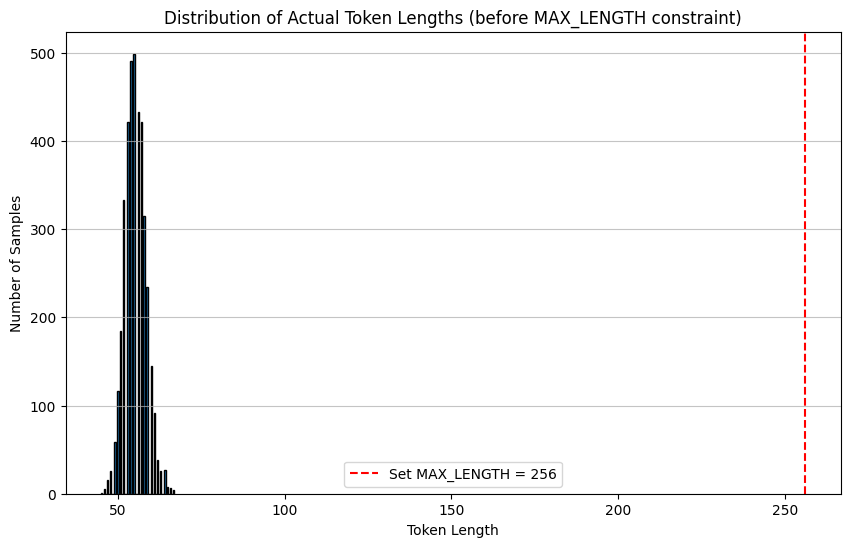

Total samples: 3902
Samples that would be truncated at MAX_LENGTH (256): 0
Percentage of samples that would be truncated: 0.00%
Truncation risk is acceptable (less than 5% of samples truncated or no truncation).


In [8]:
import matplotlib.pyplot as plt

# Calculate actual token lengths without padding or truncation
# This gives the true length of each sample before padding/truncation to MAX_LENGTH
actual_token_lengths = [len(tokenizer.encode(text, truncation=False, padding=False)) for text in df['chatml_instruction']]

# Plot histogram of actual token lengths
plt.figure(figsize=(10, 6))
plt.hist(actual_token_lengths, bins=50, edgecolor='black')
plt.title('Distribution of Actual Token Lengths (before MAX_LENGTH constraint)')
plt.xlabel('Token Length')
plt.ylabel('Number of Samples')
plt.axvline(x=MAX_LENGTH, color='red', linestyle='--', label=f'Set MAX_LENGTH = {MAX_LENGTH}')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Check for truncation risk based on actual token lengths vs. MAX_LENGTH
truncated_samples = sum(1 for length in actual_token_lengths if length > MAX_LENGTH)
truncation_percentage = (truncated_samples / len(actual_token_lengths)) * 100

print(f"Total samples: {len(actual_token_lengths)}")
print(f"Samples that would be truncated at MAX_LENGTH ({MAX_LENGTH}): {truncated_samples}")
print(f"Percentage of samples that would be truncated: {truncation_percentage:.2f}%")

if truncation_percentage > 5:
    print("Warning: More than 5% of samples are being truncated. Consider increasing MAX_LENGTH further if possible, or acknowledge the data loss.")
else:
    print("Truncation risk is acceptable (less than 5% of samples truncated or no truncation).")

# Re-assign token_lengths for downstream use if needed, or simply proceed
# For this step, we just needed the analysis based on actual lengths.
# The `tokenized_dataset` itself already has the padded/truncated versions.


#### **2.3.3 Prepare Retrieval Corpus [3 marks]**
**The Task:** Ingest the Markdown SOPs into LangChain Document objects ready to be embedded.

**Hints & Tips:**
* Use `TextLoader` from LangChain.
* Each `.md` file becomes one `Document` with `.page_content` and `.metadata`.
* These documents are embedded into ChromaDB in Notebook 4.

**Learner Inference:** These document objects form the knowledge base your bot retrieves from in Stages 3 and 4.

In [9]:

from langchain_community.document_loaders import TextLoader
import os

# Define the path to the corporate policies directory
policies_dir = '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents'

# Initialize an empty list to store LangChain Document objects
corporate_documents = []

# Loop through each Markdown file in the directory
for filename in os.listdir(policies_dir):
    if filename.endswith('.md'):
        file_path = os.path.join(policies_dir, filename)
        try:
            # Use TextLoader to load the Markdown file
            loader = TextLoader(file_path)
            documents = loader.load()
            corporate_documents.extend(documents)
        except Exception as e:
            print(f"Error loading {filename}: {e}")

print(f"Successfully loaded {len(corporate_documents)} corporate policy documents.")

# Display a sample document to verify
if corporate_documents:
    print("\nSample Corporate Document:")
    print(f"Content: {corporate_documents[0].page_content[:200]}...") # Display first 200 chars
    print(f"Metadata: {corporate_documents[0].metadata}")

/tmp/ipykernel_1532/3237846984.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


Successfully loaded 13 corporate policy documents.

Sample Corporate Document:
Content: # Technical Troubleshooting

## Scope
Covers product and platform technical issues: app crashes, login failures
caused by the client, sync errors, broken features, errors on checkout, and
performance ...
Metadata: {'source': '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/technical_troubleshooting.md'}


### **Task 2.4: Create Dataset Partitions**

#### **2.4.1 Create Train, Validation, and Test Splits [5 marks]**
**The Task:** Split the tokenized dataset into Train (80%), Validation (10%), and Test (10%) partitions using stratified sampling. Demonstrate zero data leakage across all three.

**Hints & Tips:**
* Use `train_test_split` from sklearn with `stratify=df['intent']` so every intent appears in all splits.
* Split twice: first 80/20, then split the 20% into 50/50 (giving 10%/10%).
* The validation set is not optional — it is actively used during fine-tuning (Stage 4 / Notebook 6) for loss monitoring and early stopping.
* The test set must stay completely independent — used only for final evaluation.
* Verify zero overlap with set-intersection checks: `assert len(train_set & test_set) == 0`.
* Build a `df_test` DataFrame preserving readable `text`/`intent`/`category` columns for later scoring.

**Parameter Tuning:**
* Split ratio: `80/10/10` (recommended) or `70/15/15`. Any alternative must be justified.

**Why we are doing it:** To guarantee isolated, unseen data for unbiased evaluation, and a validation set for overfitting detection.
**How we are doing it:** Stratified sklearn splits with explicit programmatic leakage verification.

**Learner Inference:** Testing on data the model trained on gives false confidence (leakage). The held-out test split proves your model handles completely new phrasing; the validation split tells you when to stop training.

In [10]:
from sklearn.model_selection import train_test_split

# Convert tokenized_dataset to DataFrame to get access to 'intent' for stratification
df_for_split = df.copy() # Use the original df for intent column
df_for_split['input_ids'] = tokenized_dataset['input_ids']
df_for_split['labels'] = tokenized_dataset['labels']
df_for_split['attention_mask'] = tokenized_dataset['attention_mask']

# Create a unique identifier for each sample based on its content (input_ids) to verify leakage
df_for_split['content_hash'] = df_for_split['input_ids'].apply(lambda x: hash(tuple(x)))

# Ensure 'intent' is present for stratification, if not, handle it (should be from earlier steps)
if 'intent' not in df_for_split.columns:
    raise ValueError("'intent' column not found in DataFrame for stratification.")

# Initial split: 80% train, 20% temp (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    df_for_split.index.values,
    df_for_split['intent'],
    test_size=0.2,
    random_state=42,
    stratify=df_for_split['intent']
)

# Split temp: 10% validation, 10% test (from original dataset size)
X_val, X_test, y_val, y_temp = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Get the actual data splits from the original tokenized_dataset using the indices
train_indices = list(X_train)
val_indices = list(X_val)
test_indices = list(X_test)

tokenized_train_dataset = tokenized_dataset.select(train_indices)
tokenized_val_dataset = tokenized_dataset.select(val_indices)
tokenized_test_dataset = tokenized_dataset.select(test_indices)

# Create df_test from the test_indices, preserving original columns
df_test = df.iloc[test_indices].copy()
df_test['input_ids'] = [tokenized_test_dataset[i]['input_ids'] for i in range(len(tokenized_test_dataset))]
df_test['labels'] = [tokenized_test_dataset[i]['labels'] for i in range(len(tokenized_test_dataset))]
df_test['attention_mask'] = [tokenized_test_dataset[i]['attention_mask'] for i in range(len(tokenized_test_dataset))]


print(f"Train set size: {len(tokenized_train_dataset)}")
print(f"Validation set size: {len(tokenized_val_dataset)}")
print(f"Test set size: {len(tokenized_test_dataset)}")

# Verify no data leakage
train_hashes = set(df_for_split.iloc[train_indices]['content_hash'])
val_hashes = set(df_for_split.iloc[val_indices]['content_hash'])
test_hashes = set(df_for_split.iloc[test_indices]['content_hash'])

assert len(train_hashes.intersection(val_hashes)) == 0, "Leakage between train and validation sets detected!"
assert len(train_hashes.intersection(test_hashes)) == 0, "Leakage between train and test sets detected!"
assert len(val_hashes.intersection(test_hashes)) == 0, "Leakage between validation and test sets detected!"

print("Data leakage verification successful: No overlap between train, validation, and test sets.")

Train set size: 3121
Validation set size: 390
Test set size: 391
Data leakage verification successful: No overlap between train, validation, and test sets.


---
## Save Artifacts for Downstream Notebooks

**IMPORTANT:** These cells save all datasets. Notebooks 5, 6, and 7 depend on them.

In [11]:
# Save tokenized datasets for Notebook 6
tokenized_train_dataset.save_to_disk('./tokenized_train/')
tokenized_val_dataset.save_to_disk('./tokenized_valid/')

# Save df_test.csv for Notebooks 5 and 7
df_test.to_csv('df_test.csv', index=False)

print("Train, validation, and test datasets saved successfully!")

Saving the dataset (0/1 shards):   0%|          | 0/3121 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/390 [00:00<?, ? examples/s]

Train, validation, and test datasets saved successfully!


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 3.**

- [ ] `sampled_data.csv` loaded
- [ ] **Duplicates + invalid records removed (normalised dedup)** ← _Task 2.1.1_
- [ ] Data standardised (intent=lower, category=UPPER)
- [ ] ChatML formatting applied and validated (valid JSON)
- [ ] Tokenization completed with `-100` label masking
- [ ] Token distribution analysed — truncation risk assessed
- [ ] Retrieval corpus loaded from `.md` files
- [ ] **Stratified Train/Valid/Test split** with all intents in every partition
- [ ] **Zero leakage verified** via set-intersection checks
- [ ] **`./tokenized_train/` + `./tokenized_valid/` saved** ← _CRITICAL for NB6_
- [ ] **`df_test.csv` saved** ← _CRITICAL for NB5 and NB7_

**If any item is unchecked, fix it before moving on.**

#### **2.4.2 Move Saved Artifacts to Google Drive**

To ensure the processed datasets and `df_test.csv` are persistently stored and accessible for subsequent notebooks, we will move them from the Colab environment's local storage (`/content/`) to your Google Drive.

In [19]:
import shutil
import os

DRIVE_BASE = "/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset"

os.makedirs(DRIVE_BASE, exist_ok=True)

# Copy tokenized datasets
shutil.copytree(
    "/content/tokenized_train",
    os.path.join(DRIVE_BASE, "tokenized_train"),
    dirs_exist_ok=True
)

shutil.copytree(
    "/content/tokenized_valid",
    os.path.join(DRIVE_BASE, "tokenized_valid"),
    dirs_exist_ok=True
)

print("✓ Tokenized datasets copied successfully.")
# Save df_test to Google Drive
df_test.to_csv(
    "/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/df_test.csv",
    index=False
)

print("✓ df_test.csv saved successfully.")

✓ Tokenized datasets copied successfully.
✓ df_test.csv saved successfully.


In [20]:
from datasets import load_from_disk

train = load_from_disk(
    "/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/tokenized_train"
)

print("Sequence length:", len(train[0]["input_ids"]))

Sequence length: 256
